Dataset original carregado: 101 linhas e 11 colunas.

=== Estatísticas Descritivas da Variável Idade ===
count    100.00000
mean      20.53000
std        2.49628
min       18.00000
25%       18.00000
50%       19.00000
75%       23.00000
max       24.00000
Name: Age, dtype: float64


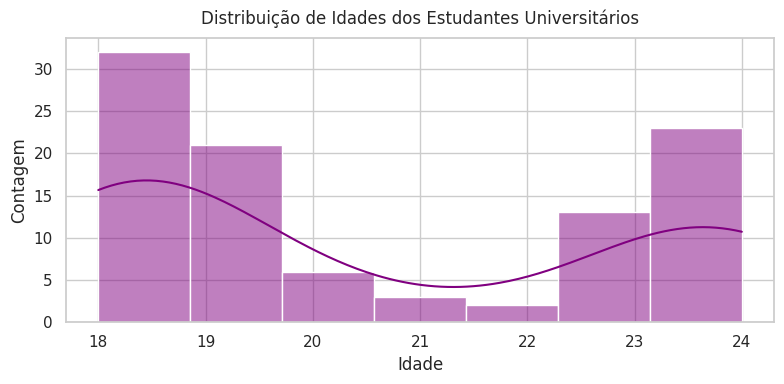

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Configuração visual dos gráficos para o relatório/slides
sns.set_theme(style="whitegrid")

# 1. Carregar o dataset original enviado para a raiz do Colab
df = pd.read_csv("StudentMentalhealth.csv")
print(f"Dataset original carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")

# 2. Exibir estatísticas descritivas da variável Idade
print("\n=== Estatísticas Descritivas da Variável Idade ===")
print(df["Age"].describe())

# 3. Gerar o histograma de distribuição de idades
plt.figure(figsize=(8, 4))
sns.histplot(df["Age"], kde=True, color="purple", bins=7)
plt.title("Distribuição de Idades dos Estudantes Universitários", fontsize=12, pad=10)
plt.xlabel("Idade")
plt.ylabel("Contagem")
plt.tight_layout()
plt.show()



In [13]:
print(f"Formato inicial do dataset: {df.shape}")

# 1. Remover registos duplicados (caso existam)
df = df.drop_duplicates()

# 2. Remover registos nulos (elimina a linha com a idade em falta)
df = df.dropna()

print(f"Formato final após a curadoria: {df.shape}")
print(f"Quantidade de valores nulos restantes: {df.isnull().sum().sum()}")

# 3. Exportar a base de dados tratada para o repositório do GitHub
df.to_csv("dados_filtrados.csv", index=False)
print("\nFicheiro 'dados_filtrados.csv' gerado e guardado com sucesso no Colab!")



Formato inicial do dataset: (101, 11)
Formato final após a curadoria: (100, 11)
Quantidade de valores nulos restantes: 0

Ficheiro 'dados_filtrados.csv' gerado e guardado com sucesso no Colab!


In [14]:
# 1. Remover a coluna de Timestamp (Data/Hora) que não possui relevância preditiva
df_modelo = df.drop(columns=['Timestamp'])

# 2. Mapear textos binários simples diretamente para 1 e 0
df_modelo['Choose your gender'] = df_modelo['Choose your gender'].map({'Male': 1, 'Female': 0})
df_modelo['Marital status'] = df_modelo['Marital status'].map({'Yes': 1, 'No': 0})
df_modelo['Do you have Depression?'] = df_modelo['Do you have Depression?'].map({'Yes': 1, 'No': 0})
df_modelo['Do you have Anxiety?'] = df_modelo['Do you have Anxiety?'].map({'Yes': 1, 'No': 0})
df_modelo['Do you have Panic attack?'] = df_modelo['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})
df_modelo['Did you seek any specialist for a treatment?'] = df_modelo['Did you seek any specialist for a treatment?'].map({'Yes': 1, 'No': 0})

# 3. Aplicar One-Hot Encoding nas variáveis com múltiplos textos (Cursos, Ano de Estudo e Notas/CGPA)
df_modelo = pd.get_dummies(df_modelo, columns=['What is your course?', 'Your current year of Study', 'What is your CGPA?'], drop_first=True)

# 4. Separar em Atributos Previsores (X) e Classe Alvo (y = Depressão)
X = df_modelo.drop(columns=['Do you have Depression?']).values.astype(float)
y = df_modelo['Do you have Depression?'].values

# 5. Dividir a base de dados em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Estrutura Pronta! Amostras de Treino: {X_train.shape[0]} | Amostras de Teste: {X_test.shape[0]}")


Estrutura Pronta! Amostras de Treino: 80 | Amostras de Teste: 20


In [11]:
# 1. Remover a coluna de Timestamp (Data/Hora) que não possui relevância preditiva
df_modelo = df.drop(columns=['Timestamp'])

# 2. Mapear textos binários simples diretamente para 1 e 0
df_modelo['Choose your gender'] = df_modelo['Choose your gender'].map({'Male': 1, 'Female': 0})
df_modelo['Marital status'] = df_modelo['Marital status'].map({'Yes': 1, 'No': 0})
df_modelo['Do you have Depression?'] = df_modelo['Do you have Depression?'].map({'Yes': 1, 'No': 0})
df_modelo['Do you have Anxiety?'] = df_modelo['Do you have Anxiety?'].map({'Yes': 1, 'No': 0})
df_modelo['Do you have Panic attack?'] = df_modelo['Do you have Panic attack?'].map({'Yes': 1, 'No': 0})
df_modelo['Did you seek any specialist for a treatment?'] = df_modelo['Did you seek any specialist for a treatment?'].map({'Yes': 1, 'No': 0})

# 3. Aplicar One-Hot Encoding nas variáveis com múltiplos textos (Cursos, Ano de Estudo e Notas/CGPA)
df_modelo = pd.get_dummies(df_modelo, columns=['What is your course?', 'Your current year of Study', 'What is your CGPA?'], drop_first=True)

# 4. Separar em Atributos Previsores (X) e Classe Alvo (y = Depressão)
X = df_modelo.drop(columns=['Do you have Depression?']).values.astype(float)
y = df_modelo['Do you have Depression?'].values

# 5. Dividir a base de dados em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Estrutura Pronta! Amostras de Treino: {X_train.shape[0]} | Amostras de Teste: {X_test.shape[0]}")


Estrutura Pronta! Amostras de Treino: 80 | Amostras de Teste: 20


In [10]:
def calcular_distancia_euclidiana(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))

class KNNManual:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        # O KNN armazena os dados de treino na memória
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        # Realiza a previsão para cada registo do conjunto de teste
        return np.array([self._prever_amostra(x) for x in X])

    def _prever_amostra(self, x):
        # 1. Calcular a distância do ponto atual para todos os pontos de treino
        distancias = [calcular_distancia_euclidiana(x, x_treino) for x_treino in self.X_train]

        # 2. Obter os índices dos K vizinhos mais próximos
        k_indices = np.argsort(distancias)[:self.k]

        # 3. Extrair as classes correspondentes desses vizinhos
        classes_vizinhos = [self.y_train[i] for i in k_indices]

        # 4. Realizar a votação majoritária
        votos, contagens = np.unique(classes_vizinhos, return_counts=True)
        return votos[np.argmax(contagens)]

# Inicializar e correr o modelo KNN manual com K=3
modelo_manual = KNNManual(k=3)
modelo_manual.fit(X_train, y_train)
preds_manual = modelo_manual.predict(X_test)
print("Previsões com KNN Manual finalizadas com sucesso!")


Previsões com KNN Manual finalizadas com sucesso!


In [9]:
# Inicializar e treinar o KNN do Scikit-Learn com o mesmo K=3
modelo_sklearn = KNeighborsClassifier(n_neighbors=3)
modelo_sklearn.fit(X_train, y_train)
preds_sklearn = modelo_sklearn.predict(X_test)
print("Previsões com Scikit-Learn finalizadas com sucesso!")


Previsões com Scikit-Learn finalizadas com sucesso!


======= DESEMPENHO: KNN MANUAL =======
Acurácia Geral: 0.7000
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        15
           1       0.33      0.20      0.25         5

    accuracy                           0.70        20
   macro avg       0.55      0.53      0.53        20
weighted avg       0.66      0.70      0.67        20


======= DESEMPENHO: KNN SCIKIT-LEARN =======
Acurácia Geral: 0.7500
              precision    recall  f1-score   support

           0       0.78      0.93      0.85        15
           1       0.50      0.20      0.29         5

    accuracy                           0.75        20
   macro avg       0.64      0.57      0.57        20
weighted avg       0.71      0.75      0.71        20


Os dois modelos tomaram decisões 95.00% idênticas.


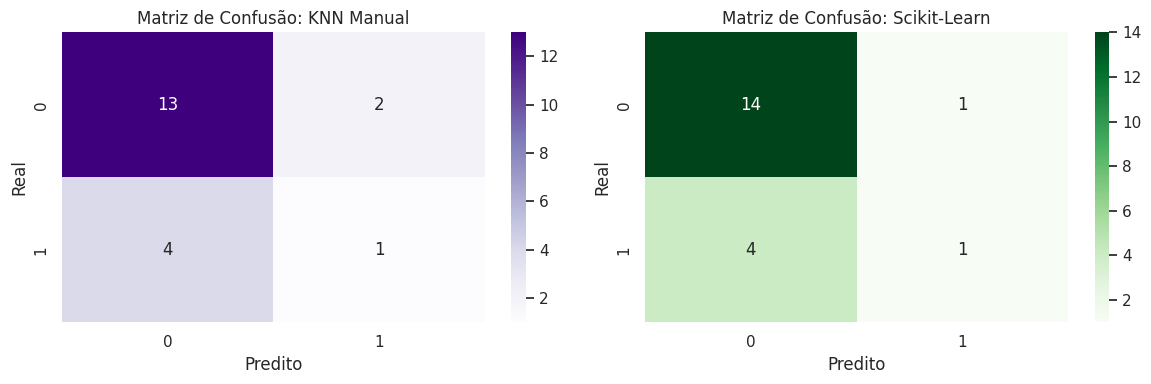

In [8]:
print("======= DESEMPENHO: KNN MANUAL =======")
print(f"Acurácia Geral: {accuracy_score(y_test, preds_manual):.4f}")
print(classification_report(y_test, preds_manual, zero_division=0))

print("\n======= DESEMPENHO: KNN SCIKIT-LEARN =======")
print(f"Acurácia Geral: {accuracy_score(y_test, preds_sklearn):.4f}")
print(classification_report(y_test, preds_sklearn, zero_division=0))

# Validação se as decisões matemáticas de ambos foram idênticas
taxa_equivalencia = np.mean(preds_manual == preds_sklearn) * 100
print(f"\nOs dois modelos tomaram decisões {taxa_equivalencia:.2f}% idênticas.")

# Desenhar as matrizes de confusão lado a lado
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, preds_manual), annot=True, fmt='d', cmap='Purples', ax=ax[0])
ax[0].set_title('Matriz de Confusão: KNN Manual')
ax[0].set_xlabel('Predito')
ax[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, preds_sklearn), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Matriz de Confusão: Scikit-Learn')
ax[1].set_xlabel('Predito')
ax[1].set_ylabel('Real')
plt.tight_layout()
plt.show()
